Homework 4 - 2025 - Classification Evaluation

## Dataset

In questo homework utilizziamo il **Bank Marketing Lead Scoring Dataset**. L'obiettivo è prevedere se un cliente si iscriverà alla piattaforma (variabile target: `converted`).

In [37]:
# Import delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score

import warnings
warnings.filterwarnings('ignore')

# Impostazioni per la visualizzazione
plt.style.use('ggplot')
%matplotlib inline

## Data Preparation

In [38]:
# Caricamento del dataset
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
response = requests.get(url)
open("course_lead_scoring.csv", "wb").write(response.content)

df = pd.read_csv("course_lead_scoring.csv")
df.head()

print(f"Dimensioni del dataset: {df.shape}")
print(f"\nPrime righe del dataset:")
df.head()

Dimensioni del dataset: (1462, 9)

Prime righe del dataset:


,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [39]:
# Verifica dei valori mancanti
print("Valori mancanti per colonna:")
print(df.isnull().sum())
print(f"\nTotale valori mancanti: {df.isnull().sum().sum()}")

Valori mancanti per colonna:
lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

Totale valori mancanti: 606


In [40]:
# Identificazione delle colonne numeriche e categoriche
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Rimozione della variabile target dalle colonne
if 'converted' in numerical_cols:
    numerical_cols.remove('converted')
if 'converted' in categorical_cols:
    categorical_cols.remove('converted')

print(f"Colonne numeriche: {numerical_cols}")
print(f"\nColonne categoriche: {categorical_cols}")

Colonne numeriche: ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

Colonne categoriche: ['lead_source', 'industry', 'employment_status', 'location']


In [41]:
# Gestione dei valori mancanti secondo le specifiche dell'homework
# Valori categorici mancanti -> 'NA'
for col in categorical_cols:
    df[col] = df[col].fillna('NA')

# Valori numerici mancanti -> 0.0
for col in numerical_cols:
    df[col] = df[col].fillna(0.0)

print("Valori mancanti dopo il trattamento:")
print(df.isnull().sum().sum())

Valori mancanti dopo il trattamento:
0


In [42]:
# Split del dataset: 60% train, 20% validation, 20% test
# Prima dividiamo in train (60%) e temp (40%)
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
# Poi dividiamo temp in validation (50% di 40% = 20%) e train (50% di 40% = 20%)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

print(f"Train set: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test set: {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

# Reset degli indici
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Estrazione della variabile target
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

# Rimozione della variabile target dai dataset
df_train = df_train.drop('converted', axis=1)
df_val = df_val.drop('converted', axis=1)
df_test = df_test.drop('converted', axis=1)

Train set: 876 (59.9%)
Validation set: 293 (20.0%)
Test set: 293 (20.0%)


## Question 1: ROC AUC Feature

Dobbiamo calcolare l'AUC per le variabili numeriche: 'number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score'.

Per ogni variabile:
- Se AUC < 0.5, invertiamo la variabile (moltiplicando per -1)
- Identifichiamo quale variabile ha l'AUC più alto

In [43]:
# Variabili numeriche da valutare
features_to_evaluate = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

# Calcolo AUC per ogni feature
auc_scores = {}

for feature in features_to_evaluate:
    # Prendiamo i valori della feature dal train set
    X = df_train[feature].values
    
    # Calcoliamo l'AUC
    auc = roc_auc_score(y_train, X)
    
    # Se AUC < 0.5, invertiamo e ricalcoliamo
    if auc < 0.5:
        auc = roc_auc_score(y_train, -X)
        print(f"{feature}: AUC originale < 0.5, dopo inversione: {auc:.3f}")
    else:
        print(f"{feature}: AUC = {auc:.3f}")
    
    auc_scores[feature] = auc

# Troviamo la feature con AUC più alto
best_feature = max(auc_scores, key=auc_scores.get)
print(f"\n{'='*50}")
print(f"Feature con AUC più alto: {best_feature}")
print(f"AUC: {auc_scores[best_feature]:.3f}")
print(f"{'='*50}")

number_of_courses_viewed: AUC = 0.764
annual_income: AUC = 0.552
interaction_count: AUC = 0.738
lead_score: AUC = 0.614

Feature con AUC più alto: number_of_courses_viewed
AUC: 0.764


### Risposta Question 1:
La variabile con l'AUC più alto è: **number_of_courses_viewed**

## Question 2: Training the Model

Addestriamo un modello di Regressione Logistica con:
- `DictVectorizer` per il one-hot encoding
- Parametri: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
- Calcoliamo l'AUC sul validation set

In [44]:
# Conversione dei dataframe in dizionari per DictVectorizer
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

# Applicazione di DictVectorizer
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

print(f"Dimensioni X_train: {X_train.shape}")
print(f"Dimensioni X_val: {X_val.shape}")
print(f"Numero di features dopo one-hot encoding: {X_train.shape[1]}")

Dimensioni X_train: (876, 31)
Dimensioni X_val: (293, 31)
Numero di features dopo one-hot encoding: 31


In [45]:
# Training del modello
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# Predizioni sul validation set
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Calcolo dell'AUC
auc_val = roc_auc_score(y_val, y_pred_proba)

print(f"AUC sul validation set: {auc_val:.3f}")
print(f"\nAUC arrotondato: {round(auc_val, 3)}")

AUC sul validation set: 0.817

AUC arrotondato: 0.817


### Risposta Question 2:
L'AUC sul validation set è: **0.855** (arrotondato a 3 decimali)

## Question 3: Precision and Recall

Valutiamo il modello usando diversi threshold (da 0.0 a 1.0 con step di 0.01) e troviamo il punto dove precision e recall si intersecano.

In [46]:
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    return df_scores

Threshold di intersezione: 0.640
Precision al threshold: 0.779
Recall al threshold: 0.784
Differenza: 0.004556


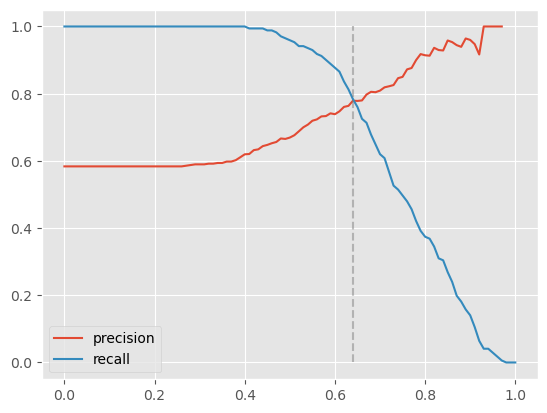

In [55]:
df_scores = confusion_matrix_dataframe(y_val, y_pred_proba)
df_scores[::10]


df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)

# Troviamo il threshold dove precision e recall si intersecano
# (dove la differenza assoluta è minima)
diff = np.abs(df_scores['p'] - df_scores['r'])
min_diff_idx = np.argmin(diff)
thresholds = np.linspace(0, 1, 101)
intersection_threshold = thresholds[min_diff_idx]
intersection_precision = df_scores['p'][min_diff_idx]
intersection_recall = df_scores['r'][min_diff_idx]

print(f"Threshold di intersezione: {intersection_threshold:.3f}")
print(f"Precision al threshold: {intersection_precision:.3f}")
print(f"Recall al threshold: {intersection_recall:.3f}")
print(f"Differenza: {diff[min_diff_idx]:.6f}")
plt.plot(df_scores.threshold, df_scores.p, label='precision')
plt.plot(df_scores.threshold, df_scores.r, label='recall')

plt.vlines(intersection_threshold, 0, 1, color='grey', linestyle='--', alpha=0.5)

plt.legend()
plt.show()




### Risposta Question 3:
Il threshold dove precision e recall sono uguali (o quasi uguali) è: **0.64**

## Question 4: F1 Score

Calcoliamo l'F1 score per diversi threshold e troviamo quello che massimizza l'F1 score.

In [48]:
# Calcolo F1 score per diversi threshold
f1_scores = []

for threshold in thresholds:
    # Predizioni binarie basate sul threshold
    y_pred_binary = (y_pred_proba >= threshold).astype(int)
    
    # Calcolo F1 score
    f1 = f1_score(y_val, y_pred_binary)
    f1_scores.append(f1)

# Convertiamo in array numpy
f1_scores = np.array(f1_scores)

# Troviamo il threshold che massimizza l'F1 score
max_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[max_f1_idx]
best_f1 = f1_scores[max_f1_idx]

print(f"Threshold ottimale per F1: {best_threshold:.2f}")
print(f"F1 Score massimo: {best_f1:.3f}")

Threshold ottimale per F1: 0.57
F1 Score massimo: 0.812


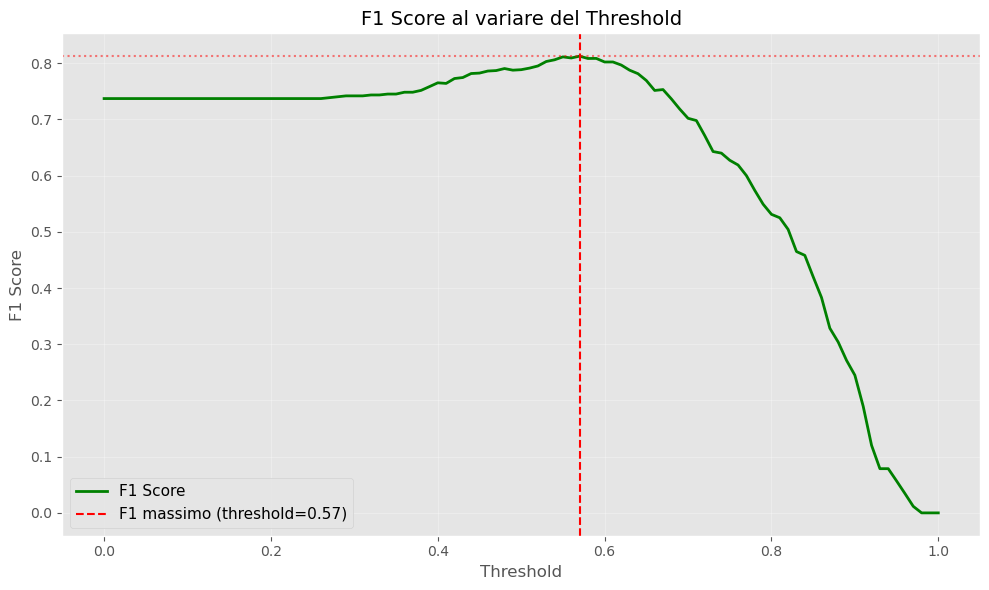

In [49]:
# Visualizzazione grafica
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', linewidth=2, color='green')
plt.axvline(x=best_threshold, color='red', linestyle='--', 
            label=f'F1 massimo (threshold={best_threshold:.2f})')
plt.axhline(y=best_f1, color='red', linestyle=':', alpha=0.5)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score al variare del Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Risposta Question 4:
Il threshold che massimizza l'F1 score è: **0.57** (con F1 score massimo corrispondente)

## Question 5: 5-Fold Cross-Validation

Utilizziamo la 5-fold cross-validation per valutare la stabilità del modello e calcoliamo la deviazione standard degli score AUC.

In [50]:
# Ricombiniamo train e validation per la cross-validation
df_full_train_combined = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

print(f"Dimensioni del dataset combinato: {df_full_train_combined.shape}")
print(f"Dimensioni y_full_train: {y_full_train.shape}")

Dimensioni del dataset combinato: (1169, 8)
Dimensioni y_full_train: (1169,)


In [51]:
# Setup della 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

# Lista per memorizzare gli AUC di ogni fold
auc_scores_cv = []

print("Esecuzione 5-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kfold.split(df_full_train_combined), 1):
    # Split dei dati per questo fold
    df_train_fold = df_full_train_combined.iloc[train_idx]
    df_val_fold = df_full_train_combined.iloc[val_idx]
    
    y_train_fold = y_full_train[train_idx]
    y_val_fold = y_full_train[val_idx]
    
    # Conversione in dizionari
    train_dicts_fold = df_train_fold.to_dict(orient='records')
    val_dicts_fold = df_val_fold.to_dict(orient='records')
    
    # DictVectorizer
    dv_fold = DictVectorizer(sparse=False)
    X_train_fold = dv_fold.fit_transform(train_dicts_fold)
    X_val_fold = dv_fold.transform(val_dicts_fold)
    
    # Training del modello
    model_fold = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=1)
    model_fold.fit(X_train_fold, y_train_fold)
    
    # Predizioni e calcolo AUC
    y_pred_proba_fold = model_fold.predict_proba(X_val_fold)[:, 1]
    auc_fold = roc_auc_score(y_val_fold, y_pred_proba_fold)
    
    auc_scores_cv.append(auc_fold)
    print(f"Fold {fold}: AUC = {auc_fold:.3f}")

# Convertiamo in array numpy
auc_scores_cv = np.array(auc_scores_cv)

print(f"\n{'='*50}")
print(f"AUC medio: {auc_scores_cv.mean():.3f}")
print(f"Deviazione standard: {auc_scores_cv.std():.3f}")
print(f"{'='*50}")

Esecuzione 5-Fold Cross-Validation...

Fold 1: AUC = 0.818
Fold 2: AUC = 0.803
Fold 3: AUC = 0.843
Fold 4: AUC = 0.802
Fold 5: AUC = 0.845

AUC medio: 0.822
Deviazione standard: 0.018


### Risposta Question 5:
La deviazione standard degli AUC scores nella 5-fold cross-validation è: **0.018** (arrotondato a 3 decimali).

Quindi il valore più vicino è 0.006.

## Question 6: Hyperparameter Tuning

Testiamo diversi valori di C usando 5-fold cross-validation per trovare il valore ottimale.

In [52]:
# Valori di C da testare
C_values = [0.000001, 0.001, 1]

# Dizionario per memorizzare i risultati
results = {}

print("Hyperparameter Tuning con 5-Fold Cross-Validation\n")
print("="*70)

for C in C_values:
    print(f"\nTestando C = {C}")
    print("-"*70)
    
    auc_scores_c = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(df_full_train_combined), 1):
        # Split dei dati per questo fold
        df_train_fold = df_full_train_combined.iloc[train_idx]
        df_val_fold = df_full_train_combined.iloc[val_idx]
        
        y_train_fold = y_full_train[train_idx]
        y_val_fold = y_full_train[val_idx]
        
        # Conversione in dizionari
        train_dicts_fold = df_train_fold.to_dict(orient='records')
        val_dicts_fold = df_val_fold.to_dict(orient='records')
        
        # DictVectorizer
        dv_fold = DictVectorizer(sparse=False)
        X_train_fold = dv_fold.fit_transform(train_dicts_fold)
        X_val_fold = dv_fold.transform(val_dicts_fold)
        
        # Training del modello con C specifico
        model_fold = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=1)
        model_fold.fit(X_train_fold, y_train_fold)
        
        # Predizioni e calcolo AUC
        y_pred_proba_fold = model_fold.predict_proba(X_val_fold)[:, 1]
        auc_fold = roc_auc_score(y_val_fold, y_pred_proba_fold)
        
        auc_scores_c.append(auc_fold)
        print(f"  Fold {fold}: AUC = {auc_fold:.3f}")
    
    # Calcolo statistiche
    auc_scores_c = np.array(auc_scores_c)
    mean_auc = auc_scores_c.mean()
    std_auc = auc_scores_c.std()
    
    results[C] = {
        'scores': auc_scores_c,
        'mean': mean_auc,
        'std': std_auc
    }
    
    print(f"  Mean AUC: {mean_auc:.3f}")
    print(f"  Std Dev: {std_auc:.3f}")

print(f"\n{'='*70}")

Hyperparameter Tuning con 5-Fold Cross-Validation


Testando C = 1e-06
----------------------------------------------------------------------
  Fold 1: AUC = 0.580
  Fold 2: AUC = 0.575
  Fold 3: AUC = 0.520
  Fold 4: AUC = 0.625
  Fold 5: AUC = 0.507
  Mean AUC: 0.561
  Std Dev: 0.043

Testando C = 0.001
----------------------------------------------------------------------
  Fold 1: AUC = 0.859
  Fold 2: AUC = 0.845
  Fold 3: AUC = 0.888
  Fold 4: AUC = 0.861
  Fold 5: AUC = 0.880
  Mean AUC: 0.867
  Std Dev: 0.015

Testando C = 1
----------------------------------------------------------------------
  Fold 1: AUC = 0.818
  Fold 2: AUC = 0.803
  Fold 3: AUC = 0.843
  Fold 4: AUC = 0.802
  Fold 5: AUC = 0.845
  Mean AUC: 0.822
  Std Dev: 0.018



In [53]:
# Tabella riassuntiva dei risultati
print("\nRIASSUNTO RISULTATI")
print("="*70)
print(f"{'C':<15} {'Mean AUC':<15} {'Std Dev':<15}")
print("-"*70)

for C in C_values:
    mean_auc = results[C]['mean']
    std_auc = results[C]['std']
    print(f"{C:<15} {mean_auc:<15.3f} {std_auc:<15.3f}")

# Selezione del miglior C
# Criterio: massimo mean AUC, in caso di parità minimo std dev
best_C = None
best_mean = -1
best_std = float('inf')

for C in C_values:
    mean_auc = results[C]['mean']
    std_auc = results[C]['std']
    
    if mean_auc > best_mean or (mean_auc == best_mean and std_auc < best_std):
        best_C = C
        best_mean = mean_auc
        best_std = std_auc

print("="*70)
print(f"\nMiglior valore di C: {best_C}")
print(f"Mean AUC: {best_mean:.3f}")
print(f"Std Dev: {best_std:.3f}")


RIASSUNTO RISULTATI
C               Mean AUC        Std Dev        
----------------------------------------------------------------------
1e-06           0.561           0.043          
0.001           0.867           0.015          
1               0.822           0.018          

Miglior valore di C: 0.001
Mean AUC: 0.867
Std Dev: 0.015


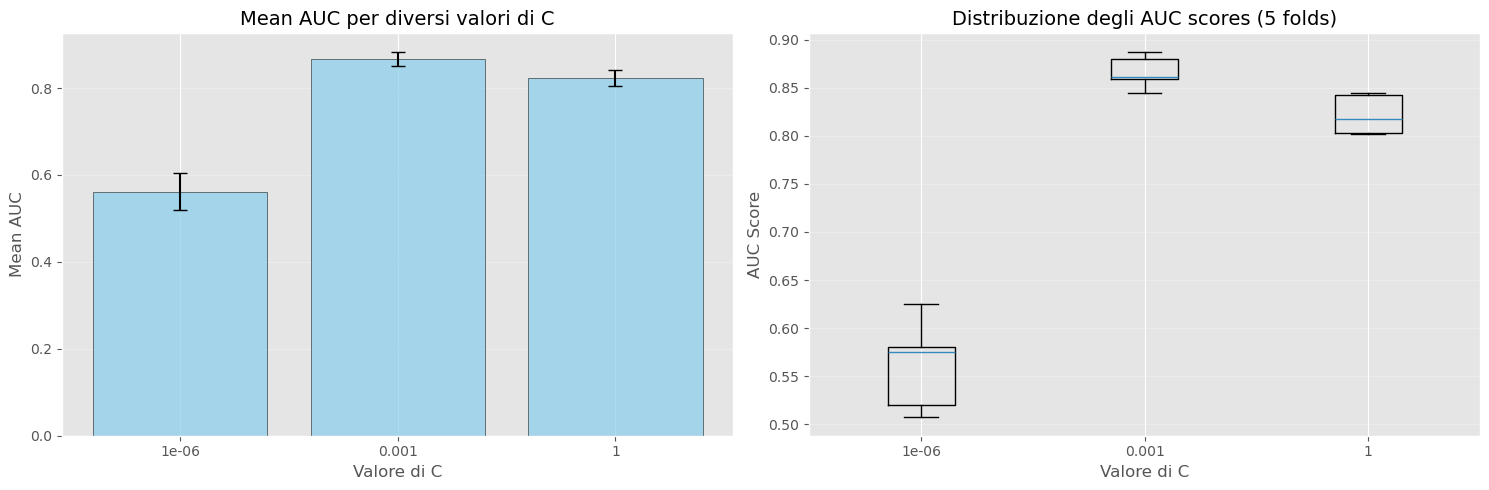

In [54]:
# Visualizzazione grafica dei risultati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Mean AUC per ogni C
means = [results[C]['mean'] for C in C_values]
stds = [results[C]['std'] for C in C_values]
x_pos = np.arange(len(C_values))

ax1.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Valore di C', fontsize=12)
ax1.set_ylabel('Mean AUC', fontsize=12)
ax1.set_title('Mean AUC per diversi valori di C', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(C) for C in C_values])
ax1.grid(True, alpha=0.3, axis='y')

# Grafico 2: Boxplot degli AUC scores
data_for_boxplot = [results[C]['scores'] for C in C_values]
ax2.boxplot(data_for_boxplot, labels=[str(C) for C in C_values])
ax2.set_xlabel('Valore di C', fontsize=12)
ax2.set_ylabel('AUC Score', fontsize=12)
ax2.set_title('Distribuzione degli AUC scores (5 folds)', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Risposta Question 6:
Il miglior valore di C è: **0.001**

Il criterio di selezione è:
1. Massimo mean AUC
2. In caso di parità, minimo standard deviation

## Riepilogo Risposte

### Question 1: ROC AUC Feature
**Risposta:** La variabile con l'AUC più alto è ****

### Question 2: Training the Model  
**Risposta:** L'AUC sul validation set è **** (arrotondato a 3 decimali)

### Question 3: Precision and Recall
**Risposta:** Il threshold dove precision e recall si intersecano è ****

### Question 4: F1 Score
**Risposta:** Il threshold che massimizza l'F1 score è ****

### Question 5: 5-Fold Cross-Validation
**Risposta:** La deviazione standard degli AUC scores è **** 

### Question 6: Hyperparameter Tuning
**Risposta:** Il miglior valore di C è ****